In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('sales.csv')
df

,order_id,customer,product,date,price,quantity
0,1,John,Laptop,2024-01-05,800,1
1,2,Alice,Mouse,2024-01-06,20,2
2,3,David,Keyboard,2024-01-08,50,1
3,4,John,Monitor,2024-02-02,200,1
4,5,Emma,Laptop,2024-02-10,800,1
5,6,Alice,Keyboard,2024-02-15,50,2
6,7,David,Mouse,2024-03-01,20,3
7,8,John,Laptop,2024-03-05,800,1
8,9,Emma,Monitor,2024-03-07,200,1
9,10,Alice,Laptop,2024-03-10,800,1


In [3]:
df.head()

,order_id,customer,product,date,price,quantity
0,1,John,Laptop,2024-01-05,800,1
1,2,Alice,Mouse,2024-01-06,20,2
2,3,David,Keyboard,2024-01-08,50,1
3,4,John,Monitor,2024-02-02,200,1
4,5,Emma,Laptop,2024-02-10,800,1


In [4]:
df.tail()

,order_id,customer,product,date,price,quantity
15,16,Emma,Laptop,2024-05-06,800,1
16,17,John,Mouse,2024-06-01,20,5
17,18,Alice,Keyboard,2024-06-03,50,1
18,19,David,Monitor,2024-06-07,200,1
19,20,Emma,Keyboard,2024-06-10,50,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  20 non-null     int64 
 1   customer  20 non-null     object
 2   product   20 non-null     object
 3   date      20 non-null     object
 4   price     20 non-null     int64 
 5   quantity  20 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 1.1+ KB


In [7]:
df.describe()

,order_id,price,quantity
count,20.00000,20.000000,20.000000
mean,10.50000,299.000000,1.600000
std,5.91608,342.481655,1.142481
min,1.00000,20.000000,1.000000
25%,5.75000,50.000000,1.000000
50%,10.50000,125.000000,1.000000
75%,15.25000,800.000000,2.000000
max,20.00000,800.000000,5.000000


In [18]:
df.isnull()
df.isnull().sum()

order_id    0
customer    0
product     0
date        0
price       0
quantity    0
revenue     0
month       0
dtype: int64

In [19]:
df.drop_duplicates(inplace=True)

In [9]:
df["revenue"] = df["price"] * df["quantity"]
df

,order_id,customer,product,date,price,quantity,revenue
0,1,John,Laptop,2024-01-05,800,1,800
1,2,Alice,Mouse,2024-01-06,20,2,40
2,3,David,Keyboard,2024-01-08,50,1,50
3,4,John,Monitor,2024-02-02,200,1,200
4,5,Emma,Laptop,2024-02-10,800,1,800
5,6,Alice,Keyboard,2024-02-15,50,2,100
6,7,David,Mouse,2024-03-01,20,3,60
7,8,John,Laptop,2024-03-05,800,1,800
8,9,Emma,Monitor,2024-03-07,200,1,200
9,10,Alice,Laptop,2024-03-10,800,1,800


In [11]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df

,order_id,customer,product,date,price,quantity,revenue,month
0,1,John,Laptop,2024-01-05,800,1,800,1
1,2,Alice,Mouse,2024-01-06,20,2,40,1
2,3,David,Keyboard,2024-01-08,50,1,50,1
3,4,John,Monitor,2024-02-02,200,1,200,2
4,5,Emma,Laptop,2024-02-10,800,1,800,2
5,6,Alice,Keyboard,2024-02-15,50,2,100,2
6,7,David,Mouse,2024-03-01,20,3,60,3
7,8,John,Laptop,2024-03-05,800,1,800,3
8,9,Emma,Monitor,2024-03-07,200,1,200,3
9,10,Alice,Laptop,2024-03-10,800,1,800,3


In [12]:
monthly_revenue = df.groupby("month")["revenue"].sum()
print(monthly_revenue)

month
1     890
2    1100
3    1860
4     180
5    1800
6     450
Name: revenue, dtype: int64


In [14]:
top5_customers = df.groupby("customer")["revenue"].sum().sort_values(ascending=False).head(5)

print(top_customers)

customer
Emma     1980
John     1950
Alice    1190
David    1160
Name: revenue, dtype: int64


In [15]:
least5_customer=df.groupby("customer")["revenue"].sum().sort_values(ascending=True).head(5)
print(least5_customer)

customer
David    1160
Alice    1190
John     1950
Emma     1980
Name: revenue, dtype: int64


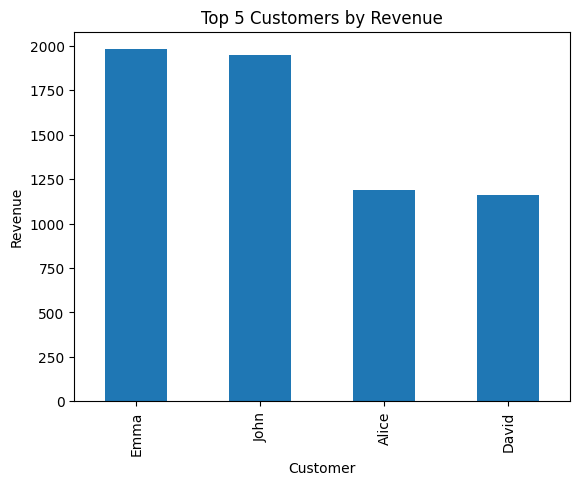

In [24]:
import matplotlib.pyplot as plt 

top_customers.plot(kind='bar')

plt.title("Top 5 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

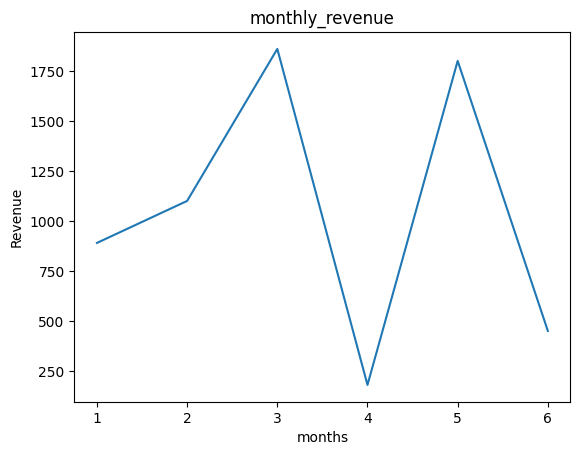

In [26]:
monthly_revenue.plot(kind='line')

plt.title("monthly_revenue")
plt.xlabel("months")
plt.ylabel("Revenue")

plt.show()

In [27]:
df.groupby("product")["quantity"].sum().sort_values(ascending=False)

product
Mouse       14
Keyboard     8
Laptop       6
Monitor      4
Name: quantity, dtype: int64

In [28]:
monthly_revenue.sort_values(ascending=False)

month
3    1860
5    1800
2    1100
1     890
6     450
4     180
Name: revenue, dtype: int64

In [31]:
df["revenue"].mean() //average revenue

AttributeError: 'Series' object has no attribute 'avg'